# Landslide field vs validation points, in a notebook

A Landlab landslide probability field (`landslide__probability_of_failure`) scored against the mapped landslide points for Pioneer / Stehekin.

Install once: `pip install -e ~/landlab-grid-validation`. Edit the paths in the next cell.

In [1]:
from pathlib import Path
import geopandas as gpd
try:
    import landlab_grid_validation  # installed
except ImportError:
    import sys; sys.path.insert(0, str(Path.cwd().parent / "src"))  # run from the repo
from landlab_grid_validation import (FieldSpec, compare_fields_on_grid, grid_from_raster,
                                     plot_comparison, raster_to_node_field, vector_to_node_field)

DATA = Path("/mnt/c/Users/amehedi/Downloads/pioneer")
LANDSLIDE = DATA / "landslide__probability_of_failure.tif"
POINTS = DATA / "Initiation_Points_final/Initiation_Points_final.shp"
ABSENCE = DATA / "negative_points/random90_unbiased.shp"

## 1. The Landlab grid and the landslide field

`grid_from_raster` puts every node at its cell centre, so points land in the right cell. Avoid `landlab.io.esri_ascii.load` on a file with `XLLCORNER`: it puts nodes on cell corners, half a cell off, and here 73 of the 89 points would land in the wrong cell without any error.

In [2]:
grid, crs = grid_from_raster(LANDSLIDE)
grid.add_field("landslide__probability_of_failure",
               raster_to_node_field(grid, crs, LANDSLIDE), at="node")
print(grid.shape, grid.dx, crs)

(1085, 893) 30.0 EPSG:32610


## 2. The validation points as a field on the same grid

One 30 m cell per point. Negatives are the pseudo-absence cells that hold no initiation of any type.

In [3]:
points = gpd.read_file(POINTS).to_crs(crs)
landslides = points[points.FailureTyp == "LS"]
grid.add_field("landslide__observed", vector_to_node_field(grid, crs, landslides), at="node")

absence = vector_to_node_field(grid, crs, ABSENCE)
any_initiation = vector_to_node_field(grid, crs, points)
mask = (grid.at_node["landslide__observed"] == 1) | ((absence == 1) & (any_initiation == 0))

## 3. Compare

In [4]:
result = compare_fields_on_grid(
    grid, "landslide__probability_of_failure", "landslide__observed",
    FieldSpec(name="Landslide probability", kind="continuous", units="probability", threshold=0.5),
    FieldSpec(name="landslide points", kind="binary"),
    mask=mask,
)
{k: round(result.metrics[k], 3) for k in ("roc_auc", "recall", "precision",
                                          "true_positive", "false_negative")}

{'roc_auc': 0.636,
 'recall': 0.302,
 'precision': 0.481,
 'true_positive': 13,
 'false_negative': 30}

## 4. Plot

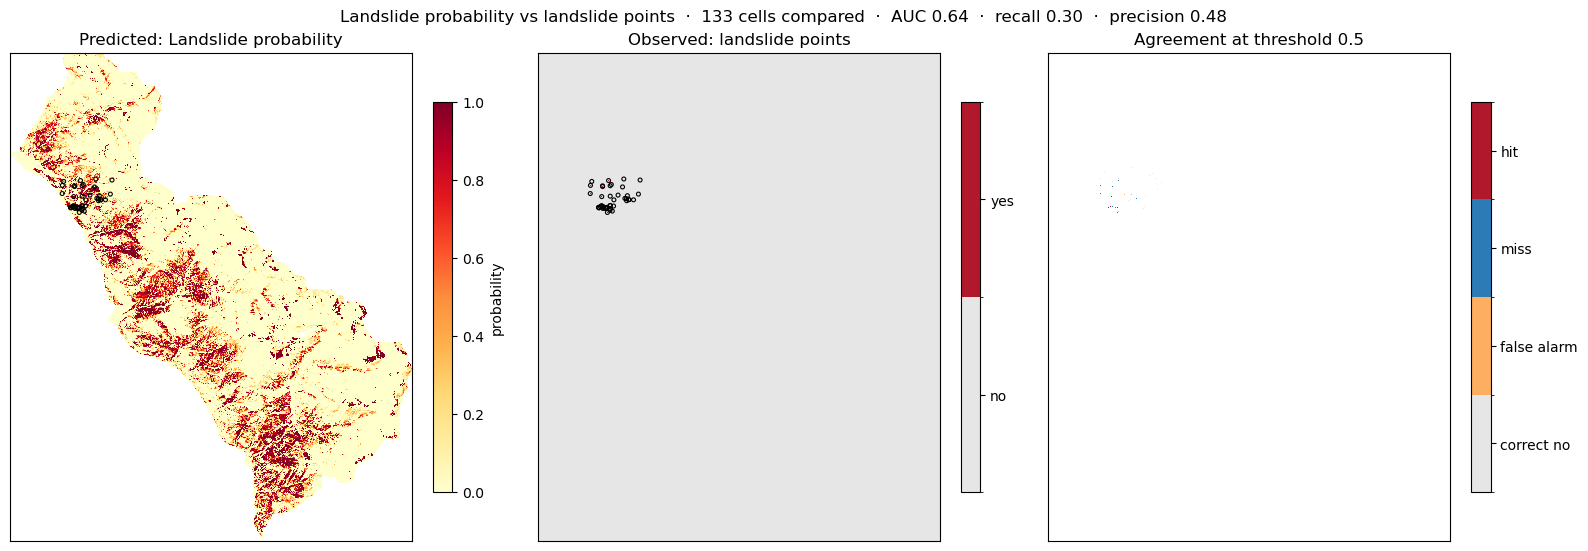

In [5]:
fig = plot_comparison(grid, result, points=landslides, marker_size=8)

## Already have a model grid in memory?

Copy its field onto a georeferenced twin (same shape, same node order), then run steps 2 to 4 on `twin`. If the field carries a no-data flag, declare it, e.g. `FieldSpec(..., nodata=-999999)`.

```python
twin, crs = grid_from_raster(LANDSLIDE)
twin.add_field("landslide__probability_of_failure",
               model_grid.at_node["landslide__probability_of_failure"], at="node")
```